# **Assignment : Heart Failure Prediction (Classification)**

1. Load Dataset
       ↓
2. Understand Dataset
       ↓
3. Data Cleaning
       ↓
4. Missing Values
       ↓
5. Duplicate Values
       ↓
6. EDA / Analysis
       ↓
7. Feature and Target Selection
       ↓
8. Encoding
       ↓
9. Train-Test Split
       ↓
10. Class Imbalance Check
       ↓
11. Feature Scaling (if required)
       ↓
12. Apply Multiple Classification Models
       ↓
13. Accuracy, Precision, Recall, F1-Score
       ↓
14. Confusion Matrix
       ↓
15. Compare Models
       ↓
16. Select Best Model
       ↓
17. Hyperparameter Tuning
       ↓
18. Final Model

# import library

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# to ignore warnings so output stays clean
import warnings
warnings.filterwarnings('ignore')

**Data load**

In [23]:
df = pd.read_csv("heart_failure_clinical_records_dataset.csv")
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


# Analysis data and EDA

In [24]:
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [25]:
df.tail()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
294,62.0,0,61,1,38,1,155000.0,1.1,143,1,1,270,0
295,55.0,0,1820,0,38,0,270000.0,1.2,139,0,0,271,0
296,45.0,0,2060,1,60,0,742000.0,0.8,138,0,0,278,0
297,45.0,0,2413,0,38,0,140000.0,1.4,140,1,1,280,0
298,50.0,0,196,0,45,0,395000.0,1.6,136,1,1,285,0


In [26]:
df.shape

(299, 13)

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


In [28]:
df.describe()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000,299.00000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870,0.32107
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000,0.00000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000,0.00000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000,1.00000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000,1.00000


In [29]:
df.isnull().sum()

,0
age,0
anaemia,0
creatinine_phosphokinase,0
diabetes,0
ejection_fraction,0
high_blood_pressure,0
platelets,0
serum_creatinine,0
serum_sodium,0
sex,0


In [30]:
df.duplicated().sum()

np.int64(0)

In [31]:
# checking how many unique values every column has
df.nunique()

,0
age,47
anaemia,2
creatinine_phosphokinase,208
diabetes,2
ejection_fraction,17
high_blood_pressure,2
platelets,176
serum_creatinine,40
serum_sodium,27
sex,2


**Findings from initial inspection:**
- The dataset has 299 rows and 13 columns.
- There are no missing values in any column.
- There are no duplicate rows.
- All columns are already numeric (int64 / float64), so no text/categorical encoding is required.
- `anaemia`, `diabetes`, `high_blood_pressure`, `sex`, `smoking` and `DEATH_EVENT` are binary (0/1) columns.
- `DEATH_EVENT` is the target column that tells us whether the patient died (1) or survived (0) during the follow-up period.

# Data Cleaning

Since there are **no missing values** and **no duplicate rows**, heavy cleaning is not required for this dataset.

We will just:
- Confirm data types are correct.
- Check for any invalid/impossible values (for example negative ages or negative platelet counts).

In [32]:
# checking for any impossible negative values in numeric columns
numeric_cols = df.select_dtypes(include=np.number).columns
(df[numeric_cols] < 0).sum()

,0
age,0
anaemia,0
creatinine_phosphokinase,0
diabetes,0
ejection_fraction,0
high_blood_pressure,0
platelets,0
serum_creatinine,0
serum_sodium,0
sex,0


No negative/invalid values were found, so the dataset is already clean and ready for analysis.

# Exploratory Data Analysis (EDA)

**Target column distribution**

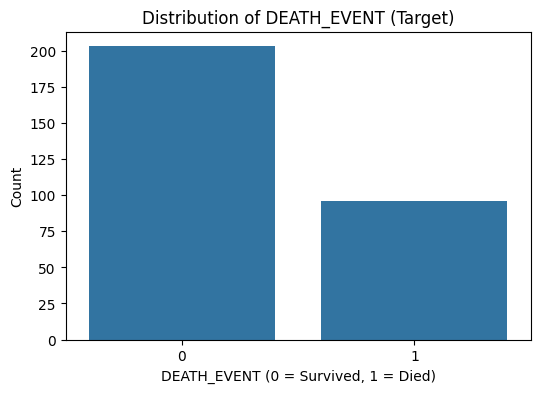

,count
DEATH_EVENT,
0,203
1,96


In [33]:
plt.figure(figsize=(6, 4))
sns.countplot(x='DEATH_EVENT', data=df)
plt.title('Distribution of DEATH_EVENT (Target)')
plt.xlabel('DEATH_EVENT (0 = Survived, 1 = Died)')
plt.ylabel('Count')
plt.show()

df['DEATH_EVENT'].value_counts()

**Distribution of numerical features**

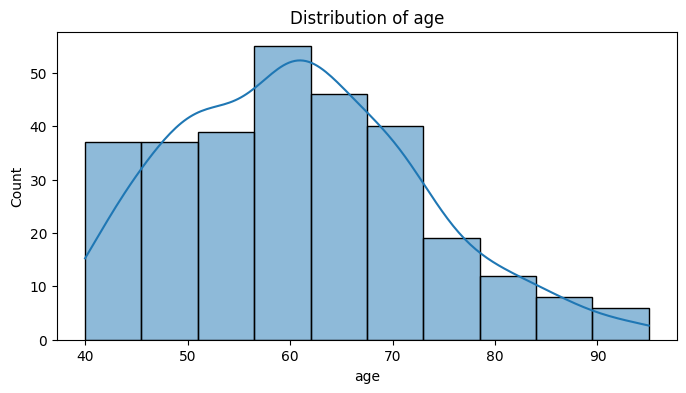

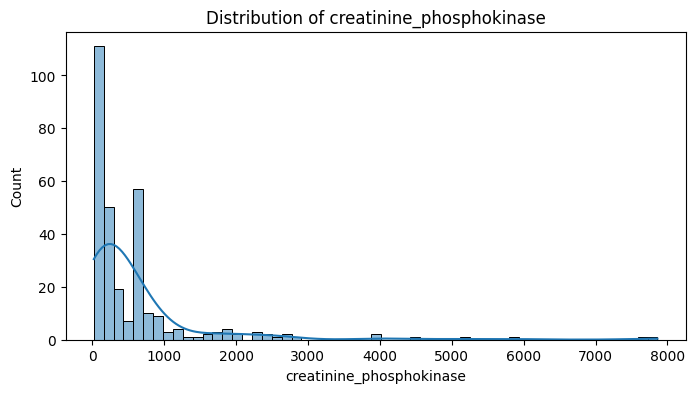

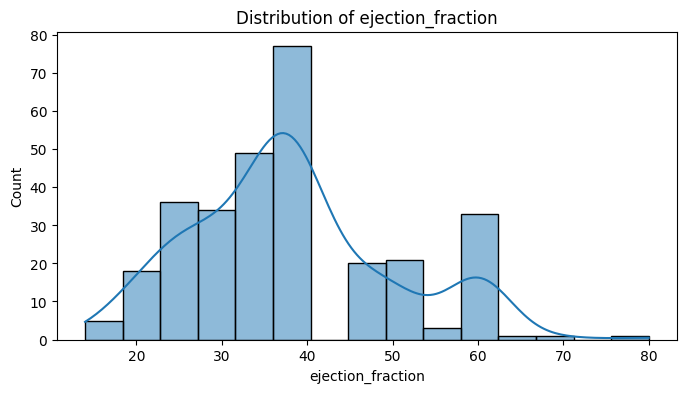

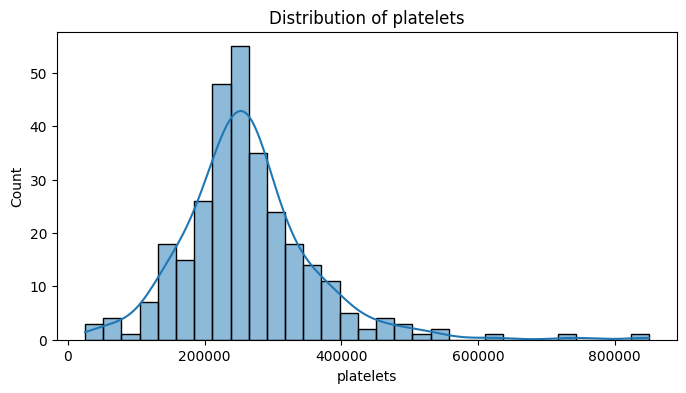

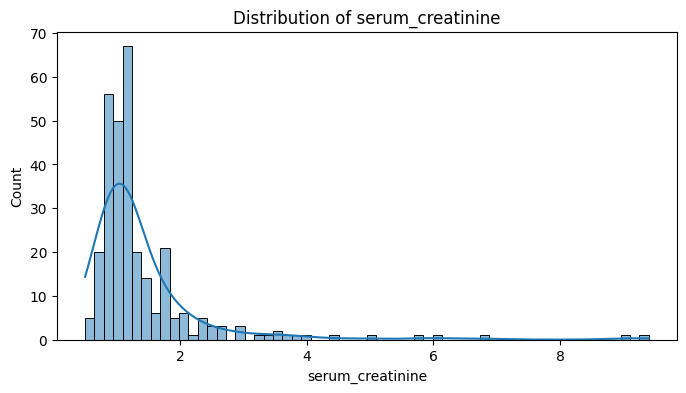

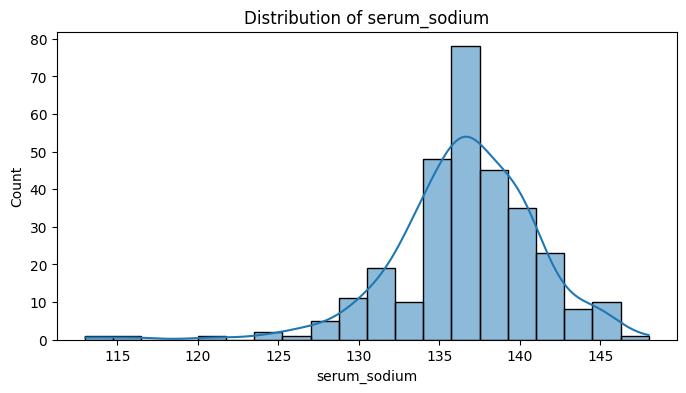

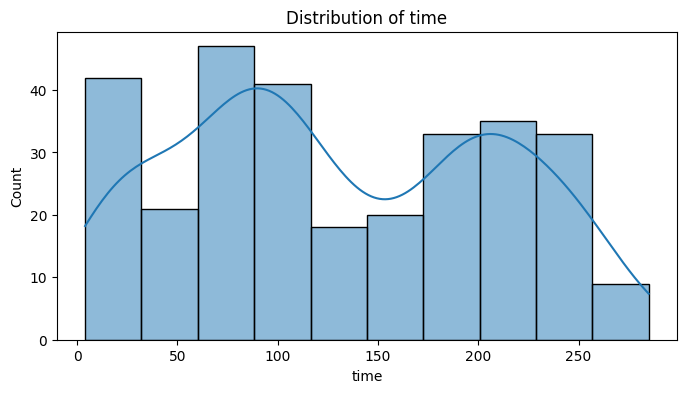

In [34]:
numeric_features = ['age', 'creatinine_phosphokinase', 'ejection_fraction',
                     'platelets', 'serum_creatinine', 'serum_sodium', 'time']

for col in numeric_features:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

**Boxplots to check outliers**

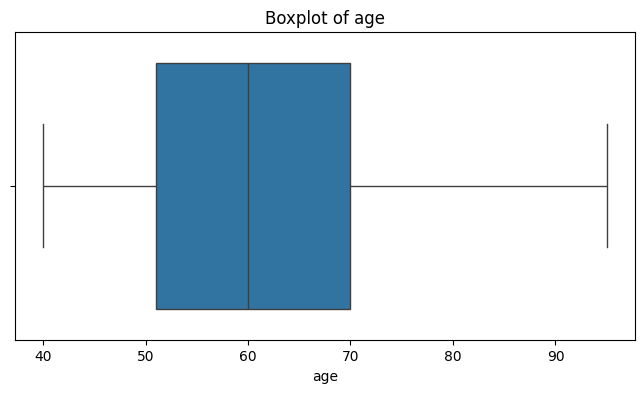

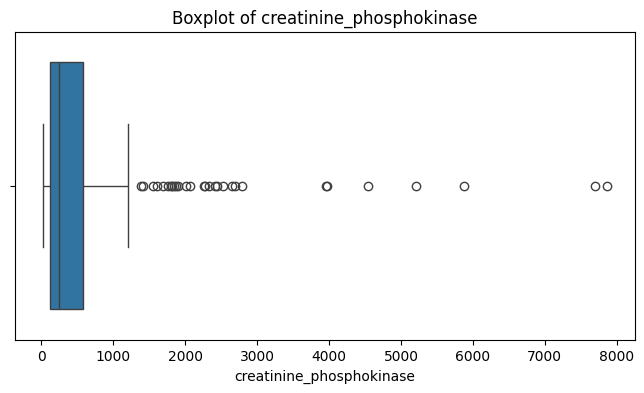

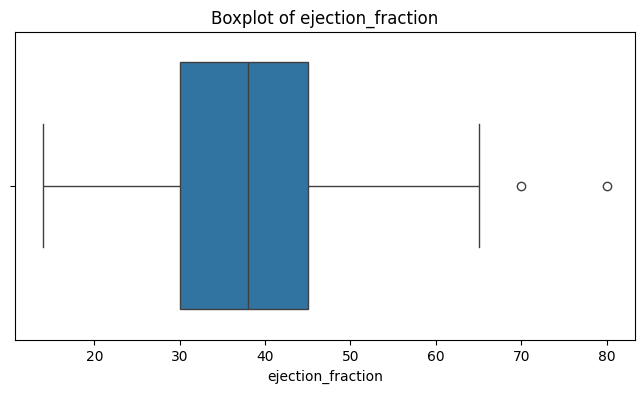

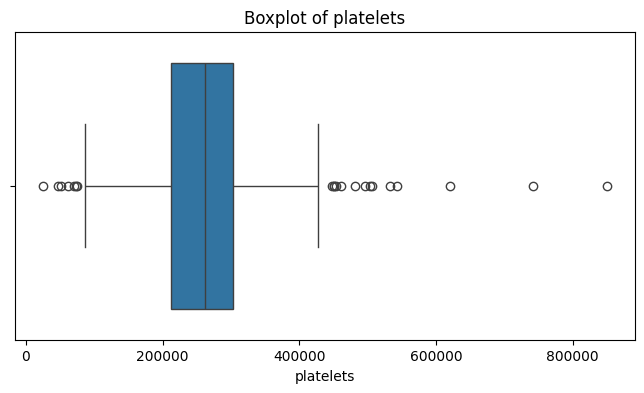

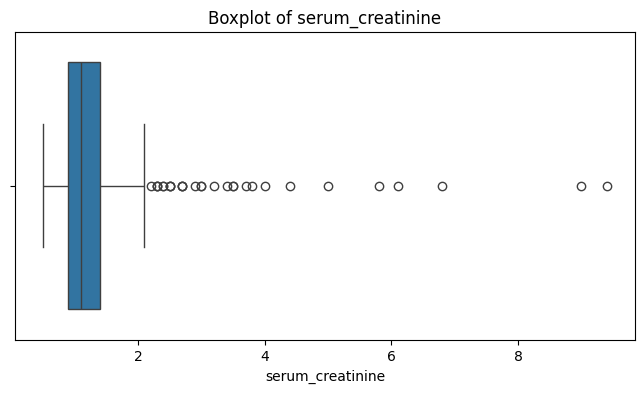

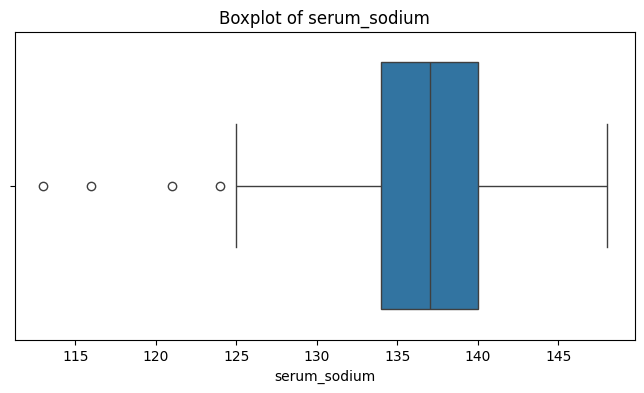

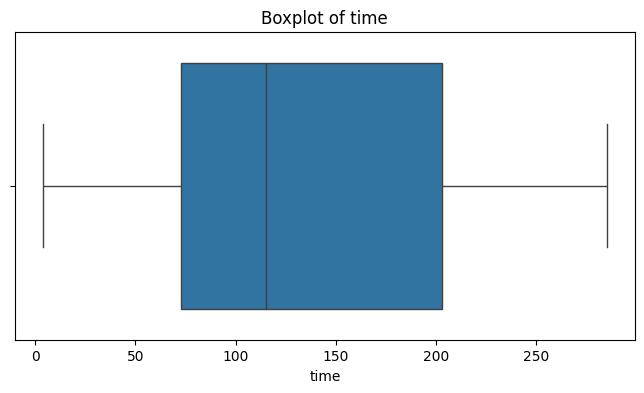

In [35]:
for col in numeric_features:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

A few numerical columns such as `creatinine_phosphokinase`, `platelets` and `serum_creatinine` show some outliers.
These are kept as they are because in medical data, unusually high values (for example very high creatinine) are often genuine
and clinically meaningful signals rather than data errors.

**Categorical-style (binary) feature analysis**

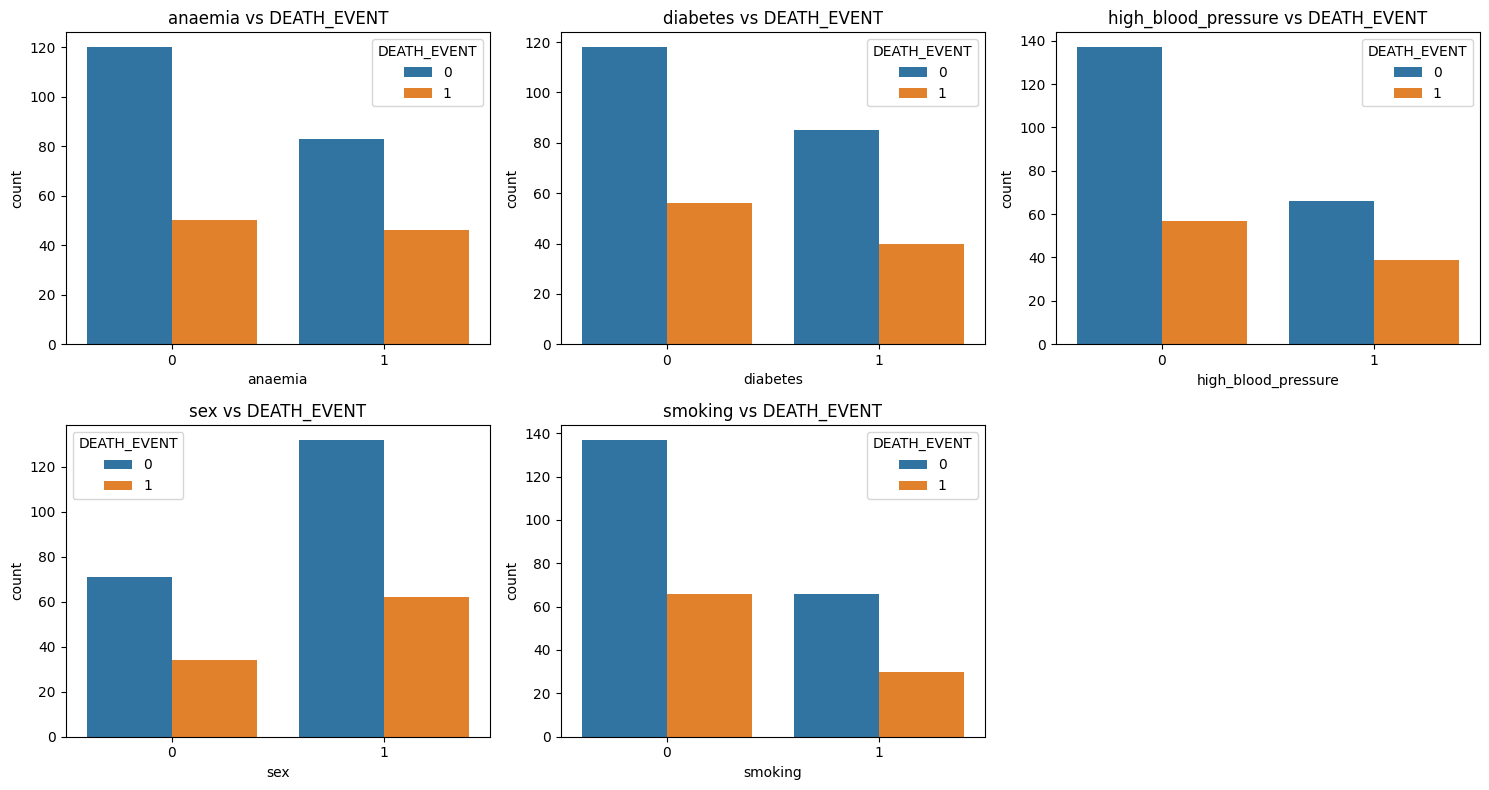

In [36]:
binary_features = ['anaemia', 'diabetes', 'high_blood_pressure', 'sex', 'smoking']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(binary_features):
    sns.countplot(x=col, hue='DEATH_EVENT', data=df, ax=axes[i])
    axes[i].set_title(f'{col} vs DEATH_EVENT')

fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

**Correlation heatmap**

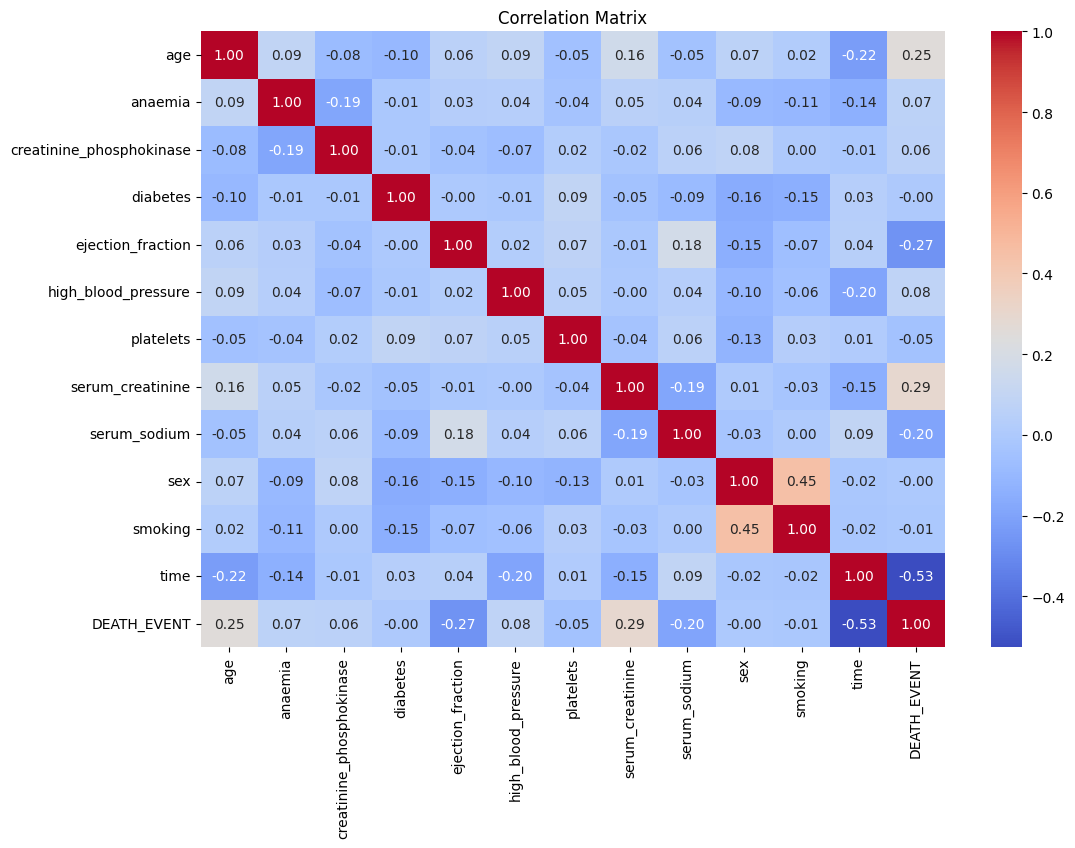

In [37]:
plt.figure(figsize=(12, 8))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

In [38]:
# checking which features are most correlated with the target
corr['DEATH_EVENT'].sort_values(ascending=False)

,DEATH_EVENT
DEATH_EVENT,1.000000
serum_creatinine,0.294278
age,0.253729
high_blood_pressure,0.079351
anaemia,0.066270
creatinine_phosphokinase,0.062728
diabetes,-0.001943
sex,-0.004316
smoking,-0.012623
platelets,-0.049139


## EDA Summary

- The dataset contains 299 records and 13 columns, with no missing values and no duplicate rows.
- The target column `DEATH_EVENT` is **imbalanced**: about 68% of patients survived (0) and about 32% died (1).
- `time` (follow-up period) has the strongest correlation with `DEATH_EVENT` — shorter follow-up time is associated with a higher chance of death.
- `serum_creatinine` and `age` are positively correlated with death, while `ejection_fraction` is negatively correlated with death (lower ejection fraction is more dangerous).
- Binary features like `sex`, `smoking`, `diabetes` do not show a very strong visual difference between the two classes.

# Separate Features (X) and Target (y)

`DEATH_EVENT` is chosen as the target column because the goal of this assignment is to **classify/predict whether a
patient will die (1) or survive (0)** based on their clinical records. All other columns are used as input features.

In [39]:
X = df.drop('DEATH_EVENT', axis=1)
y = df['DEATH_EVENT']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (299, 12)
y shape: (299,)


# Encoding

All the columns in `X` are already numeric (either continuous numbers or 0/1 binary flags). There are **no text-based
categorical columns** in this dataset, so no One-Hot Encoding or Label Encoding is required here.

In [40]:
X.dtypes

,0
age,float64
anaemia,int64
creatinine_phosphokinase,int64
diabetes,int64
ejection_fraction,int64
high_blood_pressure,int64
platelets,float64
serum_creatinine,float64
serum_sodium,int64
sex,int64


# train_test_split — separate training and testing data

In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # keeps the same proportion of DEATH_EVENT classes in train and test sets
)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)

X_train shape: (239, 12)
X_test shape : (60, 12)


# Check Class Imbalance

In [42]:
print("Training set class distribution:")
print(y_train.value_counts())
print()
print("Percentage:")
print(y_train.value_counts(normalize=True) * 100)

Training set class distribution:
DEATH_EVENT
0    162
1     77
Name: count, dtype: int64

Percentage:
DEATH_EVENT
0    67.782427
1    32.217573
Name: proportion, dtype: float64


The training data is **imbalanced**: roughly 68% of patients survived and only about 32% died. If we train models directly
on this imbalanced data, the models may become biased toward predicting the majority class (survived) and perform poorly on
the minority class (died), which is actually the more important class to detect correctly in a medical setting.

To fix this, we apply **Random Over-Sampling** to the **training data only** — the minority class (`DEATH_EVENT = 1`) is
randomly duplicated until both classes are balanced. The test set is left untouched so that evaluation reflects real-world
class proportions.

In [43]:
from sklearn.utils import resample

# combine X_train and y_train temporarily so we can resample together
train_data = X_train.copy()
train_data['DEATH_EVENT'] = y_train.values

majority = train_data[train_data.DEATH_EVENT == 0]
minority = train_data[train_data.DEATH_EVENT == 1]

# upsample the minority class to match the majority class size
minority_upsampled = resample(
    minority,
    replace=True,
    n_samples=len(majority),
    random_state=42
)

train_balanced = pd.concat([majority, minority_upsampled])

X_train_bal = train_balanced.drop('DEATH_EVENT', axis=1)
y_train_bal = train_balanced['DEATH_EVENT']

print("Balanced training class distribution:")
print(y_train_bal.value_counts())

Balanced training class distribution:
DEATH_EVENT
0    162
1    162
Name: count, dtype: int64


# Feature Scaling

Feature scaling is important here because the numerical columns have very different ranges, for example:

- `age` → roughly 40 to 95
- `creatinine_phosphokinase` → roughly 23 to 7861
- `platelets` → roughly 25,000 to 850,000
- `serum_sodium` → roughly 113 to 148

Models such as **Logistic Regression, KNN and SVM** are distance/gradient based and are sensitive to these differences in scale,
so we apply `StandardScaler`. Tree-based models (Decision Tree, Random Forest) do not strictly need scaling, but using the
same scaled data for all models keeps the workflow simple and does not hurt tree-based models.

In [44]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test)

# **Multiple Classification Models**

# **Model 1: Logistic Regression**

In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Model definition & training
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train_bal)

# Predictions
y_pred_log = log_reg.predict(X_test_scaled)
y_train_pred_log = log_reg.predict(X_train_scaled)

# Evaluation Metrics
print("================ Model 1: Logistic Regression ================")
print(f"Train Accuracy: {accuracy_score(y_train_bal, y_train_pred_log):.4f}")
print(f"Test Accuracy : {accuracy_score(y_test, y_pred_log):.4f}\n")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

================ Model 1: Logistic Regression ================
Train Accuracy: 0.8302
Test Accuracy : 0.8167

Confusion Matrix:
[[38  3]
 [ 8 11]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.93      0.87        41
           1       0.79      0.58      0.67        19

    accuracy                           0.82        60
   macro avg       0.81      0.75      0.77        60
weighted avg       0.81      0.82      0.81        60



# **Model 2: Decision Tree Classifier**

In [46]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Model definition & training
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_bal, y_train_bal)

# Predictions
y_pred_dt = dt_model.predict(X_test)
y_train_pred_dt = dt_model.predict(X_train_bal)

# Evaluation Metrics
print("================ Model 2: Decision Tree ================")
print(f"Train Accuracy: {accuracy_score(y_train_bal, y_train_pred_dt):.4f}")
print(f"Test Accuracy : {accuracy_score(y_test, y_pred_dt):.4f}\n")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

================ Model 2: Decision Tree ================
Train Accuracy: 1.0000
Test Accuracy : 0.7667

Confusion Matrix:
[[37  4]
 [10  9]]

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.90      0.84        41
           1       0.69      0.47      0.56        19

    accuracy                           0.77        60
   macro avg       0.74      0.69      0.70        60
weighted avg       0.76      0.77      0.75        60



# **Model 3: Random Forest Classifier**

In [47]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Model definition & training
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_bal, y_train_bal)

# Predictions
y_pred_rf = rf_model.predict(X_test)
y_train_pred_rf = rf_model.predict(X_train_bal)

# Evaluation Metrics
print("================ Model 3: Random Forest ================")
print(f"Train Accuracy: {accuracy_score(y_train_bal, y_train_pred_rf):.4f}")
print(f"Test Accuracy : {accuracy_score(y_test, y_pred_rf):.4f}\n")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

================ Model 3: Random Forest ================
Train Accuracy: 1.0000
Test Accuracy : 0.8500

Confusion Matrix:
[[39  2]
 [ 7 12]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.95      0.90        41
           1       0.86      0.63      0.73        19

    accuracy                           0.85        60
   macro avg       0.85      0.79      0.81        60
weighted avg       0.85      0.85      0.84        60



# **Model 4: K-Nearest Neighbors (KNN)**

In [48]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Model definition & training
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train_bal)

# Predictions
y_pred_knn = knn_model.predict(X_test_scaled)
y_train_pred_knn = knn_model.predict(X_train_scaled)

# Evaluation Metrics
print("================ Model 4: KNN ================")
print(f"Train Accuracy: {accuracy_score(y_train_bal, y_train_pred_knn):.4f}")
print(f"Test Accuracy : {accuracy_score(y_test, y_pred_knn):.4f}\n")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

================ Model 4: KNN ================
Train Accuracy: 0.8580
Test Accuracy : 0.7333

Confusion Matrix:
[[38  3]
 [13  6]]

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.93      0.83        41
           1       0.67      0.32      0.43        19

    accuracy                           0.73        60
   macro avg       0.71      0.62      0.63        60
weighted avg       0.72      0.73      0.70        60



# **Model 5: Support Vector Machine (SVM)**

In [49]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Model definition & training
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train_bal)

# Predictions
y_pred_svm = svm_model.predict(X_test_scaled)
y_train_pred_svm = svm_model.predict(X_train_scaled)

# Evaluation Metrics
print("================ Model 5: Support Vector Machine (SVM) ================")
print(f"Train Accuracy: {accuracy_score(y_train_bal, y_train_pred_svm):.4f}")
print(f"Test Accuracy : {accuracy_score(y_test, y_pred_svm):.4f}\n")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

================ Model 5: Support Vector Machine (SVM) ================
Train Accuracy: 0.9414
Test Accuracy : 0.7333

Confusion Matrix:
[[35  6]
 [10  9]]

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.85      0.81        41
           1       0.60      0.47      0.53        19

    accuracy                           0.73        60
   macro avg       0.69      0.66      0.67        60
weighted avg       0.72      0.73      0.72        60



# **Model Evaluation**

For every model we calculate Accuracy, Precision, Recall and F1-Score **on both the training data and the test data**.
Comparing train vs. test scores tells us whether a model is overfitting (very high train score but much lower test score),
underfitting (both scores low), or generalizing well (train and test scores are close). Since the classes are imbalanced, we
use `average='weighted'` for precision/recall/F1. We also print the full classification report and confusion matrix on the
test set for a more detailed picture.

In [50]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix)

def score_dict(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, average='weighted'),
        'Recall': recall_score(y_true, y_pred, average='weighted'),
        'F1-Score': f1_score(y_true, y_pred, average='weighted')
    }

def evaluate_model(name, y_train_true, y_train_pred, y_test_true, y_test_pred):
    train_scores = score_dict(y_train_true, y_train_pred)
    test_scores = score_dict(y_test_true, y_test_pred)

    print(f"===== {name} =====")
    print("Train  -> Accuracy: {:.4f}  Precision: {:.4f}  Recall: {:.4f}  F1-Score: {:.4f}".format(
        train_scores['Accuracy'], train_scores['Precision'], train_scores['Recall'], train_scores['F1-Score']))
    print("Test   -> Accuracy: {:.4f}  Precision: {:.4f}  Recall: {:.4f}  F1-Score: {:.4f}".format(
        test_scores['Accuracy'], test_scores['Precision'], test_scores['Recall'], test_scores['F1-Score']))
    print()
    print("Test Set Classification Report:")
    print(classification_report(y_test_true, y_test_pred))
    print("-" * 70)

    return {
        'Model': name,
        'Train Accuracy': train_scores['Accuracy'], 'Test Accuracy': test_scores['Accuracy'],
        'Train Precision': train_scores['Precision'], 'Test Precision': test_scores['Precision'],
        'Train Recall': train_scores['Recall'], 'Test Recall': test_scores['Recall'],
        'Train F1-Score': train_scores['F1-Score'], 'Test F1-Score': test_scores['F1-Score']
    }

In [51]:
results = []

results.append(evaluate_model("Logistic Regression", y_train_bal, y_train_pred_log, y_test, y_pred_log))
results.append(evaluate_model("Decision Tree", y_train_bal, y_train_pred_dt, y_test, y_pred_dt))
results.append(evaluate_model("Random Forest", y_train_bal, y_train_pred_rf, y_test, y_pred_rf))
results.append(evaluate_model("KNN", y_train_bal, y_train_pred_knn, y_test, y_pred_knn))
results.append(evaluate_model("SVM", y_train_bal, y_train_pred_svm, y_test, y_pred_svm))

===== Logistic Regression =====
Train  -> Accuracy: 0.8302  Precision: 0.8304  Recall: 0.8302  F1-Score: 0.8302
Test   -> Accuracy: 0.8167  Precision: 0.8133  Recall: 0.8167  F1-Score: 0.8080

Test Set Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.93      0.87        41
           1       0.79      0.58      0.67        19

    accuracy                           0.82        60
   macro avg       0.81      0.75      0.77        60
weighted avg       0.81      0.82      0.81        60

----------------------------------------------------------------------
===== Decision Tree =====
Train  -> Accuracy: 1.0000  Precision: 1.0000  Recall: 1.0000  F1-Score: 1.0000
Test   -> Accuracy: 0.7667  Precision: 0.7572  Recall: 0.7667  F1-Score: 0.7527

Test Set Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.90      0.84        41
           1       0.69      0.47      0.56      

# Confusion Matrix

A confusion matrix shows how many predictions were correct and incorrect for each class:

- **Top-left** = True Negatives (correctly predicted survived)
- **Top-right** = False Positives (predicted died, actually survived)
- **Bottom-left** = False Negatives (predicted survived, actually died) — the most critical error in this medical problem
- **Bottom-right** = True Positives (correctly predicted died)

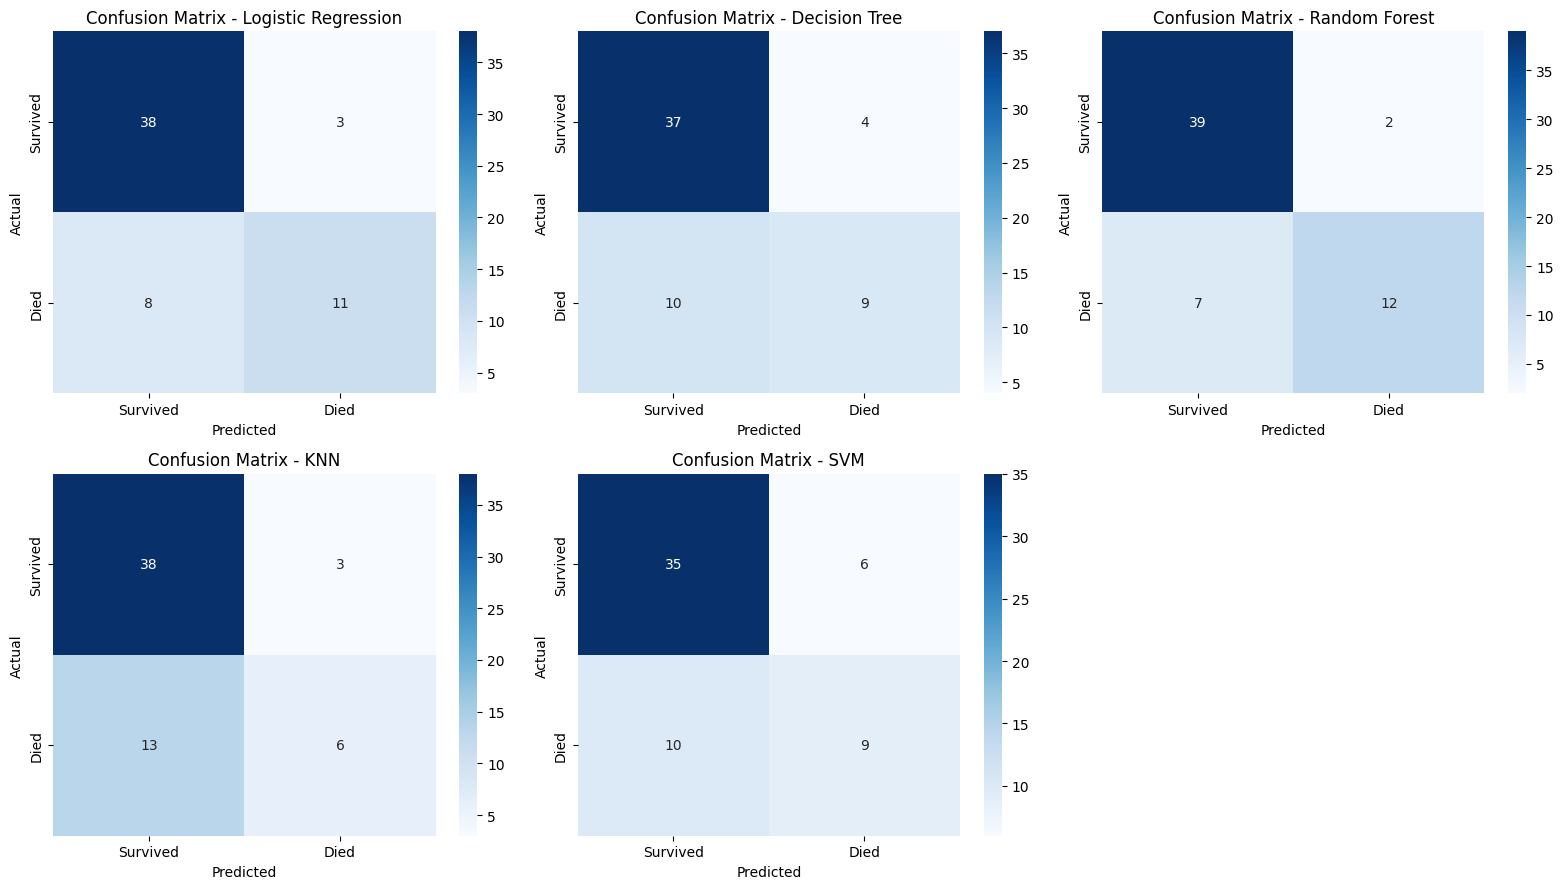

In [52]:
predictions = {
    'Logistic Regression': y_pred_log,
    'Decision Tree': y_pred_dt,
    'Random Forest': y_pred_rf,
    'KNN': y_pred_knn,
    'SVM': y_pred_svm
}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, (name, pred) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Survived', 'Died'],
                yticklabels=['Survived', 'Died'],
                ax=axes[i])
    axes[i].set_title(f'Confusion Matrix - {name}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

# **Model Comparison Table (Train vs Test)**

In [53]:
comparison_df = pd.DataFrame(results)

# order columns so Train/Test scores sit next to each other for easy comparison
comparison_df = comparison_df[['Model', 'Train Accuracy', 'Test Accuracy',
                                'Train Precision', 'Test Precision',
                                'Train Recall', 'Test Recall',
                                'Train F1-Score', 'Test F1-Score']]

# sort by Test F1-Score since that reflects real-world (unseen data) performance
comparison_df = comparison_df.sort_values(by='Test F1-Score', ascending=False).reset_index(drop=True)
comparison_df

,Model,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1-Score,Test F1-Score
0,Random Forest,1.000000,0.850000,1.000000,0.850776,1.000000,0.850000,1.000000,0.842947
1,Logistic Regression,0.830247,0.816667,0.830360,0.813302,0.830247,0.816667,0.830232,0.808046
2,Decision Tree,1.000000,0.766667,1.000000,0.757174,1.000000,0.766667,1.000000,0.752746
3,SVM,0.941358,0.733333,0.941375,0.721481,0.941358,0.733333,0.941357,0.723849
4,KNN,0.858025,0.733333,0.860000,0.720261,0.858025,0.733333,0.857830,0.700207


A large gap between the Train score and the Test score for a model is a sign of **overfitting** (the model has
memorized the training data but does not generalize well). A small gap means the model is generalizing properly.

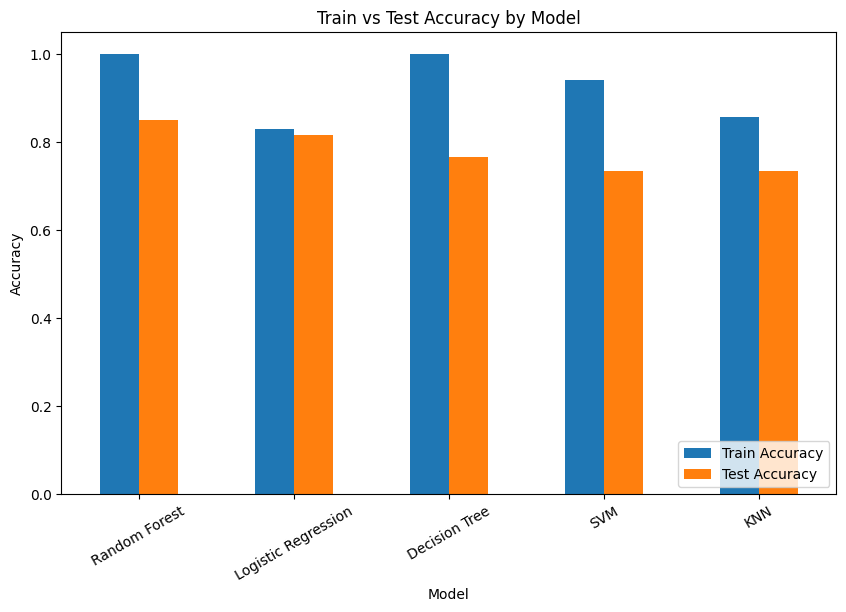

In [54]:
# visual comparison of Train vs Test Accuracy for every model
plot_df = comparison_df.set_index('Model')[['Train Accuracy', 'Test Accuracy']]
plot_df.plot(kind='bar', figsize=(10, 6))
plt.title('Train vs Test Accuracy by Model')
plt.ylabel('Accuracy')
plt.xticks(rotation=30)
plt.legend(loc='lower right')
plt.show()

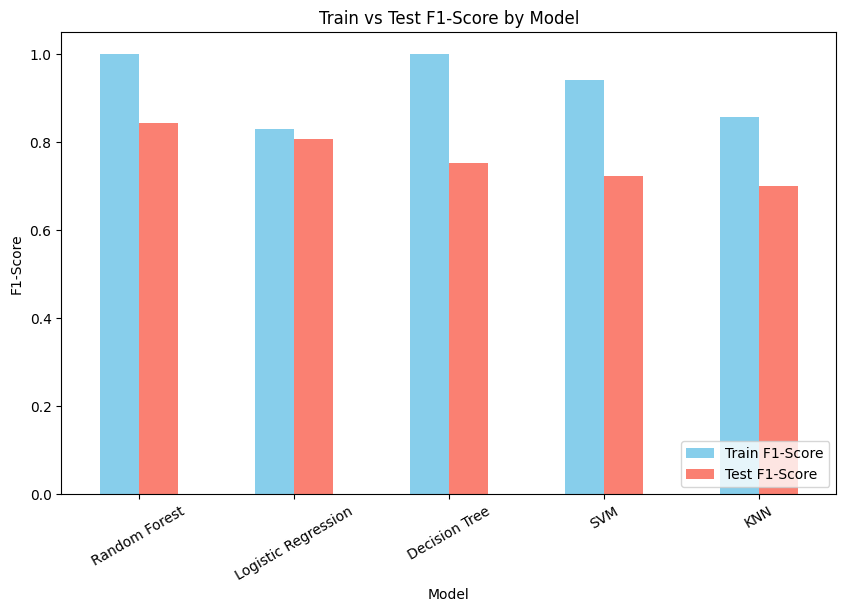

In [55]:
# visual comparison of Train vs Test F1-Score for every model
plot_df_f1 = comparison_df.set_index('Model')[['Train F1-Score', 'Test F1-Score']]
plot_df_f1.plot(kind='bar', figsize=(10, 6), color=['skyblue', 'salmon'])
plt.title('Train vs Test F1-Score by Model')
plt.ylabel('F1-Score')
plt.xticks(rotation=30)
plt.legend(loc='lower right')
plt.show()

# Select Best Model

Since `DEATH_EVENT` is imbalanced and correctly identifying patients who actually died (class 1) matters more than raw
accuracy, we select the best model based mainly on **Test F1-Score** (which balances precision and recall on unseen data),
while also checking that the Train and Test scores are not too far apart (to avoid picking an overfitted model). The model
with the highest Test F1-Score is chosen as the best-performing model and will be used for hyperparameter tuning in the next
step.

In [56]:
best_model_name = comparison_df.iloc[0]['Model']
print("Best performing model based on Test F1-Score:", best_model_name)

Best performing model based on Test F1-Score: Random Forest


# Hyperparameter Tuning

We now tune the best model found above using `GridSearchCV` with cross-validation to search for the best combination of
hyperparameters. The exact grid used depends on which model was selected as the best model.

In [57]:
from sklearn.model_selection import GridSearchCV

if best_model_name == "Random Forest":
    param_grid = {
        'n_estimators': [100, 200, 300],
        'max_depth': [None, 5, 10, 15],
        'min_samples_split': [2, 5, 10]
    }
    base_model = RandomForestClassifier(random_state=42, n_jobs=-1)
    X_tr, X_te = X_train_bal, X_test

elif best_model_name == "Decision Tree":
    param_grid = {
        'max_depth': [3, 5, 10, 15, None],
        'min_samples_split': [2, 5, 10],
        'criterion': ['gini', 'entropy']
    }
    base_model = DecisionTreeClassifier(random_state=42)
    X_tr, X_te = X_train_bal, X_test

elif best_model_name == "Logistic Regression":
    param_grid = {
        'C': [0.01, 0.1, 1, 10, 100],
        'solver': ['lbfgs', 'liblinear']
    }
    base_model = LogisticRegression(random_state=42, max_iter=1000)
    X_tr, X_te = X_train_scaled, X_test_scaled

elif best_model_name == "KNN":
    param_grid = {
        'n_neighbors': [3, 5, 7, 9, 11],
        'weights': ['uniform', 'distance']
    }
    base_model = KNeighborsClassifier()
    X_tr, X_te = X_train_scaled, X_test_scaled

else:  # SVM
    param_grid = {
        'C': [0.1, 1, 10, 100],
        'gamma': ['scale', 'auto'],
        'kernel': ['rbf']
    }
    base_model = SVC(random_state=42)
    X_tr, X_te = X_train_scaled, X_test_scaled

grid_search = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1
)

grid_search.fit(X_tr, y_train_bal)

print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation F1-Score:", grid_search.best_score_)

Best Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
Best Cross-Validation F1-Score: 0.9287623721513099


# Evaluate Tuned Model

In [58]:
tuned_model = grid_search.best_estimator_
y_pred_tuned = tuned_model.predict(X_te)
y_train_pred_tuned = tuned_model.predict(X_tr)

tuned_result = evaluate_model(f"Tuned {best_model_name}", y_train_bal, y_train_pred_tuned, y_test, y_pred_tuned)

===== Tuned Random Forest =====
Train  -> Accuracy: 1.0000  Precision: 1.0000  Recall: 1.0000  F1-Score: 1.0000
Test   -> Accuracy: 0.8500  Precision: 0.8474  Recall: 0.8500  F1-Score: 0.8462

Test Set Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.93      0.89        41
           1       0.81      0.68      0.74        19

    accuracy                           0.85        60
   macro avg       0.84      0.81      0.82        60
weighted avg       0.85      0.85      0.85        60

----------------------------------------------------------------------


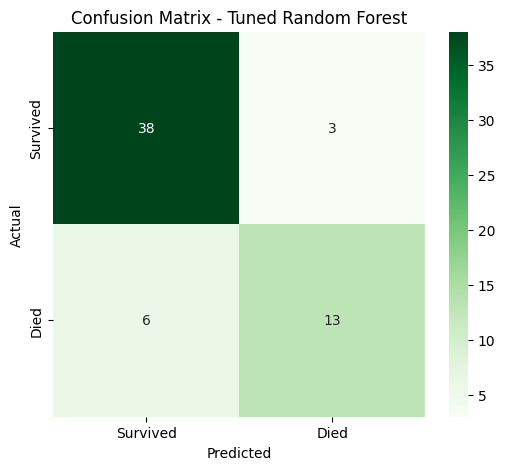

In [59]:
cm_tuned = confusion_matrix(y_test, y_pred_tuned)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Survived', 'Died'],
            yticklabels=['Survived', 'Died'])
plt.title(f'Confusion Matrix - Tuned {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [60]:
# comparing the original best model with the tuned version, on both train and test data
original_result = comparison_df.iloc[0]

comparison_final = pd.DataFrame([
    {'Model': f'{best_model_name} (Original)',
     'Train Accuracy': original_result['Train Accuracy'], 'Test Accuracy': original_result['Test Accuracy'],
     'Train Precision': original_result['Train Precision'], 'Test Precision': original_result['Test Precision'],
     'Train Recall': original_result['Train Recall'], 'Test Recall': original_result['Test Recall'],
     'Train F1-Score': original_result['Train F1-Score'], 'Test F1-Score': original_result['Test F1-Score']},
    tuned_result
])

comparison_final

,Model,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1-Score,Test F1-Score
0,Random Forest (Original),1.0,0.85,1.0,0.850776,1.0,0.85,1.0,0.842947
1,Tuned Random Forest,1.0,0.85,1.0,0.847443,1.0,0.85,1.0,0.846218


We compare the tuned model's Train/Test Accuracy, Precision, Recall and F1-Score with the original (untuned) version of
the same model above. If the tuned model's Test F1-Score is higher (and the train-test gap has not widened), hyperparameter
tuning has successfully improved the model's performance and generalization.

# **Final Model**

In [61]:
print("Final Selected Model:", f"Tuned {best_model_name}")
print("Best Hyperparameters:", grid_search.best_params_)
print()
print("Final Train Set Performance:")
print("Accuracy :", tuned_result['Train Accuracy'])
print("Precision:", tuned_result['Train Precision'])
print("Recall   :", tuned_result['Train Recall'])
print("F1-Score :", tuned_result['Train F1-Score'])
print()
print("Final Test Set Performance:")
print("Accuracy :", tuned_result['Test Accuracy'])
print("Precision:", tuned_result['Test Precision'])
print("Recall   :", tuned_result['Test Recall'])
print("F1-Score :", tuned_result['Test F1-Score'])

Final Selected Model: Tuned Random Forest
Best Hyperparameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}

Final Train Set Performance:
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-Score : 1.0

Final Test Set Performance:
Accuracy : 0.85
Precision: 0.8474431818181818
Recall   : 0.85
F1-Score : 0.8462184873949581


## Final Conclusion

After training and comparing five different classification models (Logistic Regression, Decision Tree, Random Forest, KNN
and SVM) on the heart failure clinical records dataset, the model printed below achieved the best overall performance based
on F1-Score. After applying hyperparameter tuning using GridSearchCV, the tuned model's final performance on the test set is
shown above. This model can help predict whether a patient is likely to survive or die based on their clinical measurements,
which could support doctors in identifying high-risk patients earlier.

In [62]:
print(f"The best performing model for this dataset is: Tuned {best_model_name}")
print(f"Final F1-Score on train data: {tuned_result['Train F1-Score']:.4f}")
print(f"Final F1-Score on test data : {tuned_result['Test F1-Score']:.4f}")

The best performing model for this dataset is: Tuned Random Forest
Final F1-Score on train data: 1.0000
Final F1-Score on test data : 0.8462
